<a href="https://colab.research.google.com/github/ParhamPishro/Flavonoid/blob/main/4%20Hyperparameter%20Tuning/1_KNN_HT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV


Read Data

In [2]:
df = pd.read_excel("/content/FlavonoidData.xlsx")
df


,authors,flavonoid,cell line,time,dose,viability-mean,viability-error,viability-SD,viability-SE
0,Chen et al. 2017,Luteolin,KYSE30,48,10.0,77.272727,77.272727,0.001000,NaN
1,Chen et al. 2017,Luteolin,KYSE30,48,20.0,67.613636,67.613636,0.001000,NaN
2,Chen et al. 2017,Luteolin,KYSE30,48,40.0,47.159091,47.159091,0.001000,NaN
3,Chen et al. 2017,Luteolin,KYSE30,48,80.0,32.386364,32.386364,0.001000,NaN
4,Chen et al. 2017,Luteolin,KYSE30,72,10.0,69.886364,69.886364,0.001000,NaN
...,...,...,...,...,...,...,...,...,...
479,Zhu et al. 2016,Apigenin,KYSE150,24,20.0,88.407643,88.407643,0.001000,NaN
480,Zhu et al. 2016,Apigenin,KYSE150,24,40.0,78.980892,82.802548,3.821656,NaN
481,Zhu et al. 2016,Apigenin,KYSE150,24,60.0,67.261146,70.828025,3.566879,NaN
482,Zhu et al. 2016,Apigenin,KYSE150,24,80.0,45.350318,47.643312,2.292994,NaN


Discretized Data

In [3]:
df['v01'] = 1
df.loc[df['viability-mean']>50, 'v01'] = 0


In [4]:
df = df.drop(['authors', 'viability-error', 'viability-SD', 'viability-SE'], axis=1)
df


,flavonoid,cell line,time,dose,viability-mean,v01
0,Luteolin,KYSE30,48,10.0,77.272727,0
1,Luteolin,KYSE30,48,20.0,67.613636,0
2,Luteolin,KYSE30,48,40.0,47.159091,1
3,Luteolin,KYSE30,48,80.0,32.386364,1
4,Luteolin,KYSE30,72,10.0,69.886364,0
...,...,...,...,...,...,...
479,Apigenin,KYSE150,24,20.0,88.407643,0
480,Apigenin,KYSE150,24,40.0,78.980892,0
481,Apigenin,KYSE150,24,60.0,67.261146,0
482,Apigenin,KYSE150,24,80.0,45.350318,1


Encoding

In [5]:
df_encoded = pd.get_dummies(df, dtype=int)
df_encoded

,time,dose,viability-mean,v01,flavonoid_Acacetin,flavonoid_Apigenin,flavonoid_Chrysin,flavonoid_Galangin,flavonoid_Kaempferol,flavonoid_Luteolin,...,cell line_KYSE150,cell line_KYSE30,cell line_KYSE410,cell line_KYSE450,cell line_KYSE510,cell line_OE19,cell line_OE33,cell line_TE-1,cell line_TE-10,cell line_YES2
0,48,10.0,77.272727,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
1,48,20.0,67.613636,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
2,48,40.0,47.159091,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
3,48,80.0,32.386364,1,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
4,72,10.0,69.886364,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,24,20.0,88.407643,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
480,24,40.0,78.980892,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
481,24,60.0,67.261146,0,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
482,24,80.0,45.350318,1,0,1,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0


In [6]:
X = df_encoded.drop(['viability-mean', 'v01'], axis=1)
y = df['viability-mean']
y01 = df['v01']

Initialize

In [7]:
knc = KNeighborsClassifier()


Hyperparameter Tuning

In [8]:
param_kn = {'n_neighbors': range(3, 100, 2),
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']}
gs_kn = GridSearchCV(knc, param_kn, cv=5, scoring='accuracy')
%time gs_kn.fit(X, y01)
print(gs_kn.best_params_)
print(gs_kn.best_score_)

CPU times: user 11.3 s, sys: 30.8 ms, total: 11.4 s
Wall time: 12 s
{'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'distance'}
0.9112113402061854


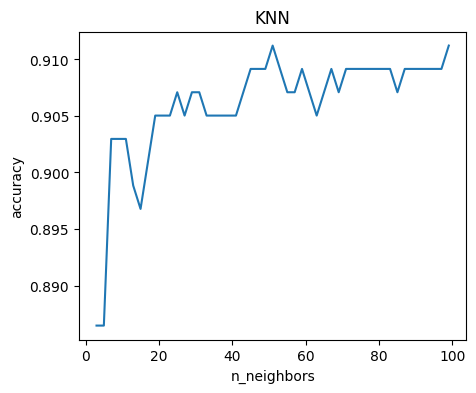

In [9]:
param_kn = {'n_neighbors': range(3, 100, 2),
            'weights': ['distance'],
            'metric': ['euclidean']}
gs_kn = GridSearchCV(knc, param_kn, cv=5, scoring='accuracy')
gs_kn.fit(X, y01)

plt.figure(figsize=(5, 4))
plt.plot(range(3, 100, 2), gs_kn.cv_results_['mean_test_score'])

plt.xlabel('n_neighbors')
plt.ylabel('accuracy')
plt.title('KNN')
#plt.ylim(.83, .87)

plt.show()

In [10]:
param_kn = {'n_neighbors': [51],
            'weights': ['uniform', 'distance'],
            'metric': ['euclidean', 'manhattan', 'minkowski']}
gs_kn = GridSearchCV(knc, param_kn, cv=5, scoring='accuracy')
gs_kn.fit(X, y01)
print(gs_kn.cv_results_['params'][0:2], gs_kn.cv_results_['mean_test_score'][0:2].max())
print(gs_kn.cv_results_['params'][2:4], gs_kn.cv_results_['mean_test_score'][2:4].max())
print(gs_kn.cv_results_['params'][4:6], gs_kn.cv_results_['mean_test_score'][4:6].max())
print(gs_kn.cv_results_['params'][0:5:2], gs_kn.cv_results_['mean_test_score'][0:5:2].max())
print(gs_kn.cv_results_['params'][1:6:2], gs_kn.cv_results_['mean_test_score'][1:6:2].max())


[{'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'uniform'}, {'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'distance'}] 0.9112113402061854
[{'metric': 'manhattan', 'n_neighbors': 51, 'weights': 'uniform'}, {'metric': 'manhattan', 'n_neighbors': 51, 'weights': 'distance'}] 0.9070876288659793
[{'metric': 'minkowski', 'n_neighbors': 51, 'weights': 'uniform'}, {'metric': 'minkowski', 'n_neighbors': 51, 'weights': 'distance'}] 0.9112113402061854
[{'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'uniform'}, {'metric': 'manhattan', 'n_neighbors': 51, 'weights': 'uniform'}, {'metric': 'minkowski', 'n_neighbors': 51, 'weights': 'uniform'}] 0.7995919243986254
[{'metric': 'euclidean', 'n_neighbors': 51, 'weights': 'distance'}, {'metric': 'manhattan', 'n_neighbors': 51, 'weights': 'distance'}, {'metric': 'minkowski', 'n_neighbors': 51, 'weights': 'distance'}] 0.9112113402061854
